In [ ]:
""" Least squares regression with statsmodels """
import numpy as np
import statsmodels.api as sm
# Generate some sample data
num_periods = 9
all_values = np.array([np.random.random(8)
for i in range(num_periods)])
# Filter the data
y_values = all_values[:, 0] # First column values as Y
x_values = all_values[:, 1:] # All other values as X
x_values = sm.add_constant(x_values) # Include the intercept
results = sm.OLS(y_values, x_values).fit()
# Regress and fit the model

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                 -0.301
Method:                 Least Squares   F-statistic:                    0.7353
Date:                Sat, 22 Aug 2026   Prob (F-statistic):              0.718
Time:                        11:38:00   Log-Likelihood:                 4.7851
No. Observations:                   9   AIC:                             6.430
Df Residuals:                       1   BIC:                             8.008
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1816      2.721     -0.067      0.958     -34.755      34.392
x1             2.0587      2.633      0.782      0.578     -31.397      35.515
x2             0.4092      1.558      0.263      0.836     -19.384      20.203
x3            -0.6372      1.477     -0.431      0.741     -19.404      18.129
x4            -0.2091      0.741     -0.282      0.825      -9.627       9.209
x5             1.6108      2.827      0.570      0.670     -34.314      37.535
x6            -1.0579      1.728     -0.612      0.650     -23.015      20.900
x7            -0.4450      1.042     -0.427      0.743     -13.683      12.792
==============================================================================
Omnibus:                        0.997   Durbin-Watson:                   1.382
Prob(Omnibus):                  0.608   Jarque-Bera (JB):                0.126
Skew:                          -0.288   Prob(JB):                        0.939
Kurtosis:                       2.936   Cond. No.                         63.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
#AAPL = سهم Apple
stock = yf.download("AAPL", start="2020-01-01")
# ^GSPC = شاخص S&P500
market = yf.download("^GSPC",start="2020-01-01")

/tmp/ipykernel_812/1090073988.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_812/1090073988.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^GSPC",start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
market

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2026-08-17,7745.060059,7790.680176,7744.879883,7790.680176,4452630000
2026-08-18,7691.759766,7713.950195,7688.629883,7700.040039,4602700000


In [ ]:
stock_returns = stock['Close'].pct_change()
market_returns = market['Close'].pct_change()

In [ ]:
data = pd.concat([stock_returns, market_returns], axis=1)
data

Ticker,AAPL,^GSPC
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007969,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016086,0.004902
...,...,...
2026-08-17,-0.001111,-0.005227
2026-08-18,0.014529,-0.006882
2026-08-19,0.021933,0.002109


In [ ]:
data.columns = ['Stock_Return', 'Market_Return']

In [ ]:
data

,Stock_Return,Market_Return
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007969,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016086,0.004902
...,...,...
2026-08-17,-0.001111,-0.005227
2026-08-18,0.014529,-0.006882
2026-08-19,0.021933,0.002109


In [ ]:
#حذف داده‌های خالی
data = data.dropna()
data

,Stock_Return,Market_Return
Date,,
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007969,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016086,0.004902
2020-01-09,0.021241,0.006655
...,...,...
2026-08-17,-0.001111,-0.005227
2026-08-18,0.014529,-0.006882
2026-08-19,0.021933,0.002109


In [ ]:
Y = data['Stock_Return']
X = data['Market_Return']
X = sm.add_constant(X)

In [ ]:
model = sm.OLS(Y, X)

results = model.fit()

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Stock_Return   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     2231.
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          1.23e-309
Time:                        11:38:00   Log-Likelihood:                 4882.6
No. Observations:                1667   AIC:                            -9761.
Df Residuals:                    1665   BIC:                            -9750.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0004      0.000      1.168

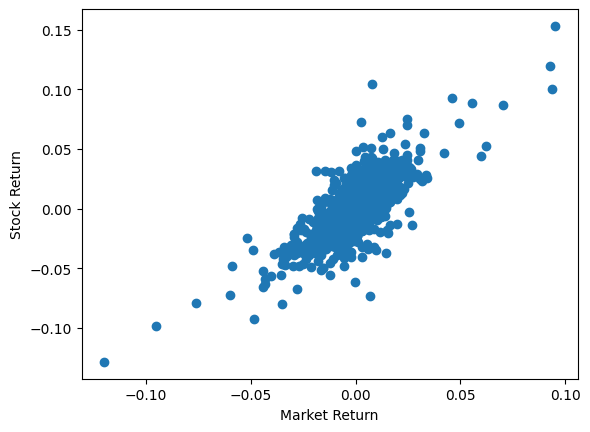

In [ ]:
plt.scatter(data['Market_Return'], data['Stock_Return'])

plt.xlabel("Market Return")
plt.ylabel("Stock Return")

plt.show()

## adding inflation and interest rate

In [ ]:
import pandas_datareader.data as web

inflation_data = web.DataReader('CPIAUCSL', 'fred', start="2020-01-01")

In [ ]:
inflation_data.head()

,CPIAUCSL
DATE,
2020-01-01,259.127
2020-02-01,259.250
2020-03-01,258.076
2020-04-01,256.032
2020-05-01,255.802


In [ ]:
# برای یکی کردن تاریخ ها و جلوگیری از nan شدن داده ها
inflation_data.index = inflation_data.index.to_period('M').to_timestamp('M')
inflation_data['Inflation'] = (inflation_data['CPIAUCSL'].pct_change(12))
inflation_data.head()

,CPIAUCSL,Inflation
DATE,,
2021-01-31,262.687,NaN
2021-02-28,263.579,NaN
2021-03-31,264.961,NaN
2021-04-30,266.614,NaN
2021-05-31,268.383,NaN


In [ ]:
inflation_data = inflation_data.dropna()
inflation_data

,CPIAUCSL,Inflation
DATE,,
2022-01-31,282.543,0.075588
2022-02-28,284.500,0.079373
2022-03-31,287.674,0.085722
2022-04-30,288.561,0.082318
2022-05-31,291.298,0.085382
2022-06-30,294.957,0.089794
2022-07-31,294.913,0.084626
2022-08-31,295.097,0.082226
2022-09-30,296.349,0.081921


In [ ]:
interest_data = web.DataReader('FEDFUNDS','fred',start="2020-01-01")
interest_data.index = interest_data.index.to_period('M').to_timestamp('M')
interest_data.head()

,FEDFUNDS
DATE,
2020-01-31,1.55
2020-02-29,1.58
2020-03-31,0.65
2020-04-30,0.05
2020-05-31,0.05


In [ ]:
stock = yf.download("AAPL", start="2020-01-01")
market = yf.download("^GSPC", start="2020-01-01")

/tmp/ipykernel_812/725120006.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_812/725120006.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^GSPC", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


## بدست اوردن بازده ماهانه لگاریتمی

In [ ]:
stock_monthly_price = stock['Close'].resample('M').last()

market_monthly_price = market['Close'].resample('M').last()

/tmp/ipykernel_812/1080869273.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stock_monthly_price = stock['Close'].resample('M').last()
/tmp/ipykernel_812/1080869273.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  market_monthly_price = market['Close'].resample('M').last()


In [ ]:
market_monthly_price

Ticker,^GSPC
Date,
2020-01-31,3225.520020
2020-02-29,2954.219971
2020-03-31,2584.590088
2020-04-30,2912.429932
2020-05-31,3044.310059
...,...
2026-04-30,7209.009766
2026-05-31,7580.060059
2026-06-30,7499.359863


In [ ]:
stock_return = (stock_monthly_price['AAPL'].pct_change(12))
market_return = (market_monthly_price['^GSPC'].pct_change(12))

In [ ]:
market_return

,^GSPC
Date,
2020-01-31,NaN
2020-02-29,NaN
2020-03-31,NaN
2020-04-30,NaN
2020-05-31,NaN
...,...
2026-04-30,0.294475
2026-05-31,0.282215
2026-06-30,0.208609


In [ ]:
data = pd.concat([stock_return, market_return,inflation_data['Inflation'],interest_data['FEDFUNDS']], axis=1)
data.columns = ['Stock_Return','Market_Return','inflation_data','Interest_Rate']

In [ ]:
data = data.dropna()
data

,Stock_Return,Market_Return,inflation_data,Interest_Rate
2022-01-31,0.332658,0.215740,0.075588,0.08
2022-02-28,0.369795,0.147669,0.079373,0.08
2022-03-31,0.437968,0.140331,0.085722,0.20
2022-04-30,0.206351,-0.011777,0.082318,0.33
2022-05-31,0.201271,-0.017117,0.085382,0.77
2022-06-30,0.003951,-0.119167,0.089794,1.21
2022-07-31,0.120516,-0.060285,0.084626,1.68
2022-08-31,0.041303,-0.125519,0.082226,2.33
2022-09-30,-0.017849,-0.167594,0.081921,2.56
2022-10-31,0.029367,-0.159249,0.077588,3.08


In [ ]:
Y = data['Stock_Return']
X = data[['Market_Return','inflation_data','Interest_Rate']]

In [ ]:
X = sm.add_constant(X)
model = sm.OLS(Y, X)

results = model.fit()

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Stock_Return   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     16.48
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.41e-07
Time:                        12:06:54   Log-Likelihood:                 36.015
No. Observations:                  54   AIC:                            -64.03
Df Residuals:                      50   BIC:                            -56.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1516      0.180      0.